## Differences between matplotlib.pyplot.imshow() and skimage.io.imshow()

You should also be aware of the differences in the default behaviour between scikit-image and matplotlib when displaying an image. The default behaviour of matplotlib.pyplot.imshow() is to use the dynamic range of the image values to plot the image. It is, if the image intensities range from [26, 173], the black colour is assigned to 26 and the white to 173. Meanwhile, skimage.io.imshow() displays the dynamic range according to the image type, [0, 255] for integer images and [0., 1.] for float images.

In [1]:
from scipy.ndimage import correlate
from skimage import color, io, measure, img_as_ubyte, img_as_float
from skimage.measure import profile_line
from skimage.transform import rescale, resize
from skimage.color import rgb2gray
import matplotlib.pyplot as plt
import numpy as np

In [2]:
input_img = np.arange(25).reshape(5, 5)
print(input_img)

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]


In [3]:
weights = [[0, 1, 0], [1, 2, 1], [0, 1, 0]]

In [4]:
res_img = correlate(input_img, weights)
target_row, target_col = 3, 3
target_matrix = np.asarray(
    [
        [input_img[target_row-1, target_col-1], input_img[target_row-1, target_col], input_img[target_row-1, target_col+1]],
        [input_img[target_row, target_col-1], input_img[target_row, target_col], input_img[target_row, target_col+1]],
        [input_img[target_row+1, target_col-1], input_img[target_row+1, target_col], input_img[target_row+1, target_col+1]],
    ]
)
# Note *, element wise multiplication
res_img[3, 3], np.sum(weights * target_matrix) 

(108, 108)

## Border handling
When the value of an output pixel at the boundary of the image is computed, a portion of the filter is usually outside the edge of the input image. One way to handle this, is to assume that the value of the off-the-edge pixels of the image are 0. This is called zero padding. Since 0 is the value of a black pixel, the output image will have a dark edge. Another approach is to reflect the actual pixel values of the image to the off-the-edge-pixel. This is the default behaviour of correlate. We can also set the off-the-edge-pixel to have a constant value (for example 10) by:

In [5]:
const_img = correlate(input_img, weights, mode="constant", cval=10)
reflect_img = correlate(input_img, weights, mode="reflect")
const_img, reflect_img

(array([[ 26,  20,  25,  30,  40],
        [ 36,  36,  42,  48,  54],
        [ 61,  66,  72,  78,  79],
        [ 86,  96, 102, 108, 104],
        [ 96, 110, 115, 120, 110]]),
 array([[  6,  11,  17,  23,  28],
        [ 31,  36,  42,  48,  53],
        [ 61,  66,  72,  78,  83],
        [ 91,  96, 102, 108, 113],
        [116, 121, 127, 133, 138]]))

## Mean filtering

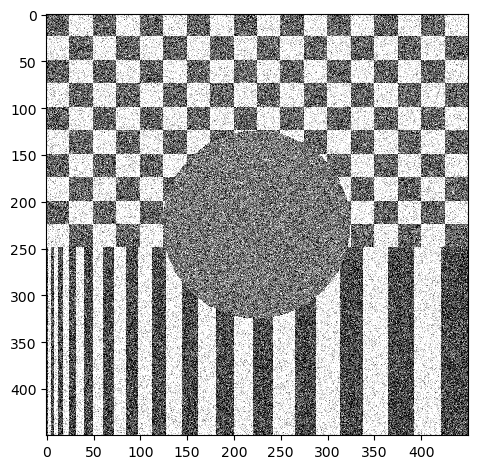

In [6]:
folder_path = "data/"
gaussian_img = rgb2gray(io.imread(folder_path + "Gaussian.png"))
io.imshow(gaussian_img)
plt.show()

In [7]:
size = 10 
# Higher sizes -> image is blurrer
# Two dimensional filter filled with 1
weights = np.ones([size, size])
# Normalize weights
weights = weights / np.sum(weights)

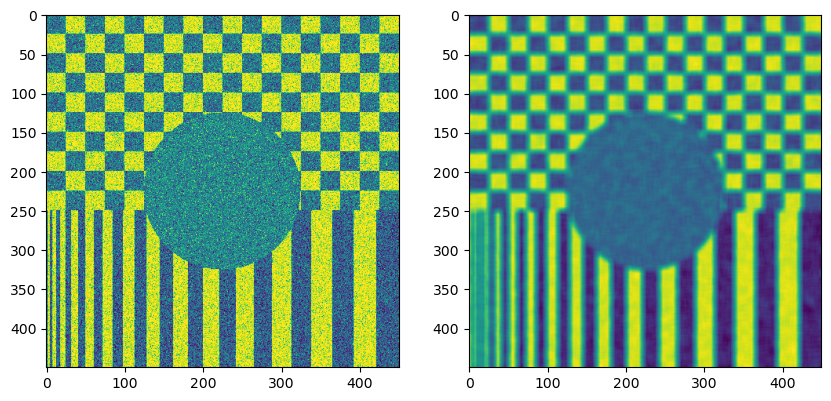

In [8]:
filtered_img = correlate(gaussian_img, weights, mode="nearest")
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 10))
ax1.imshow(gaussian_img)
ax2.imshow(filtered_img)
plt.show()

## Median filtering
The median filter belongs to the group of rank filters where the pixel values in a given area are sorted by value and then one of the values are picked. Here the median value of the sorted values.



In [9]:
from skimage.filters import median

In [10]:
salty_img = rgb2gray(io.imread(folder_path + "SaltPepper.png"))

In [11]:
size = 10
# Higher sizes -> image is blurrer
# Two dimensional filter filled with 1
weights = np.ones([size, size])
# Normalize weights
weights = weights / np.sum(weights)
mean_img = correlate(salty_img, weights, mode="nearest")

In [12]:
size = 20
footprint = np.ones([size, size])
med_img = median(salty_img, footprint)

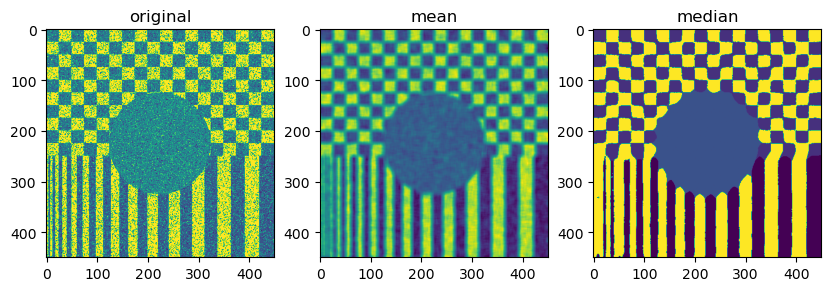

In [13]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(10, 10))
ax1.imshow(salty_img)
ax1.set_title("original")
ax2.imshow(mean_img)
ax2.set_title("mean")
ax3.imshow(med_img)
ax3.set_title("median")

plt.show()

## Gaussian filter

In [14]:
from skimage.filters import gaussian

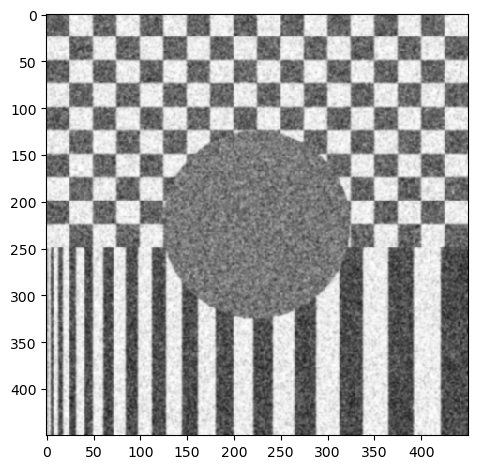

In [15]:
sigma = 1
gaussian_img = gaussian(gaussian_img, sigma)
io.imshow(gaussian_img)
plt.show()

### Expected Results with Large Kernels (>10)
Large Kernel Size: A kernel larger than 10 (e.g., 11x11, 15x15) means a bigger neighborhood is considered for each pixel, leading to stronger effects.

### Median Filter
Effect: The median filter is excellent at removing noise (like salt-and-pepper noise) while preserving edges better than simple averaging. With a large kernel:
Fine details (e.g., textures on the car’s surface, small edges) get obliterated because the median is taken over a wide area, effectively “averaging out” small variations.
Edges (light-dark transitions, like the car’s outline against the background) remain relatively sharp compared to Gaussian, but with very large kernels, even these can start to erode or become jagged if the transition spans fewer pixels than the kernel size.
Visual Result: The image looks blocky or overly simplified. At light-dark transitions (e.g., car edge), you’ll see a clear boundary, but it might shift slightly or appear stair-stepped due to the median picking values from a broad area.
### Gaussian Filter
Effect: The Gaussian filter smooths the image by applying a bell-shaped weighting, blurring everything based on distance from the center pixel. With a large kernel:
Details vanish completely—e.g., the car’s windows, wheels, or surface texture blend into a smooth gradient.
Edges (light-dark transitions) become soft and fuzzy. The transition from light to dark stretches over many pixels, losing sharpness entirely.
Visual Result: The image looks like a soft, dreamy blur. At light-dark transitions, instead of a crisp line, you get a gradual fade, making it hard to distinguish where one region ends and another begins.
### Visual Differences at Light-Dark Transitions
Median Filter: Maintains a more defined boundary. For example, if "car.png" has a bright car against a dark background, the edge stays recognizable, though it might look slightly irregular or displaced with a very large kernel.
Gaussian Filter: Softens the boundary into a gradient. The same car edge becomes a smooth fade from bright to dark, spreading the transition over a wider area, proportional to the kernel size.
Observation
Median: Better for preserving edges but sacrifices fine details. At transitions, you’ll notice a “step” that’s still visible but less natural with large kernels.
Gaussian: Creates a polished, blurry look, ideal for noise reduction but terrible for edge preservation. Transitions lose all definition, blending light and dark into a continuous smear.

## Edge filters

In image analysis, an edge is where there is a large transition from light pixels to dark pixels. It means that there is a high pixel value gradient at an edge. Since objects in an image are often of a different color than the background, the outline of the object can sometimes be found where there are edges in the image. It is therefore interesting to apply filters that can estimate the gradients in the image and using them to detect edges.

![prewitt](images/prewitt.png)

In [16]:
from skimage.filters import prewitt_h
from skimage.filters import prewitt_v
from skimage.filters import prewitt

In [21]:
donald_img = rgb2gray(io.imread(folder_path + "donald_1.png"))
donald_img

array([[0.38068   , 0.41712784, 0.4841    , ..., 0.48381725, 0.49444314,
        0.45998235],
       [0.38460157, 0.4361851 , 0.51435647, ..., 0.47989569, 0.48520118,
        0.48855725],
       [0.39748235, 0.4577651 , 0.52920941, ..., 0.49137765, 0.46083843,
        0.48603451],
       ...,
       [0.48185725, 0.52696667, 0.56451569, ..., 0.46505765, 0.44404314,
        0.3322898 ],
       [0.47820353, 0.51855804, 0.50372   , ..., 0.46700706, 0.39893373,
        0.33198431],
       [0.47092588, 0.55386706, 0.49417255, ..., 0.46926196, 0.3616902 ,
        0.38550235]])

In [18]:
pre_h = prewitt_h(donald_img)
pre_v = prewitt_v(donald_img)
donald_img.shape, pre_h.shape, pre_v.shape

((500, 500), (500, 500), (500, 500))

When you apply these filters:

High values (close to 1): Occur where there’s a strong edge in the respective direction (vertical for prewitt_h, horizontal for prewitt_v). For example, a sharp transition from dark to light vertically will yield a high positive value with prewitt_h.
Low values (close to -1): Indicate a strong edge in the opposite direction (e.g., light to dark transition).
Values near 0: Represent areas with little to no intensity change (smooth regions).
Since you’re not converting to unsigned byte, the output range remains [-1, 1], which preserves both positive and negative gradients, showing the direction of the edge transition.

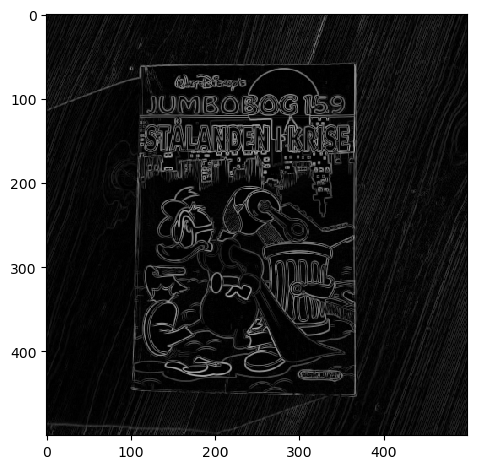

In [25]:
prewitt_full = prewitt(donald_img)
io.imshow(prewitt_full)

* Read the CT image
* Filter the image using either a Gaussian filter or a median filter
* Compute the gradients in the filtered image using a Prewitt filter
* Use Otsu's thresholding method to compute a threshold, T, in the gradient image
* Apply the threshold, T, to the gradient image to create a binary image.
The final binary should contain the edges we are looking for. It will probably contain noise as well. We will explore methods to remove this noise later in the course.

You should experiment and find out:

Does the median or Gaussian filter give the best result?
Should you use both the median and the Gaussian filter?
What filter size gives the best result?
What sigma in the Gaussian filter gives the best result?
Tip: To get a better understanding of your output, uou can use the scaled visualization and colormapping that we explored in an earlier exercise:

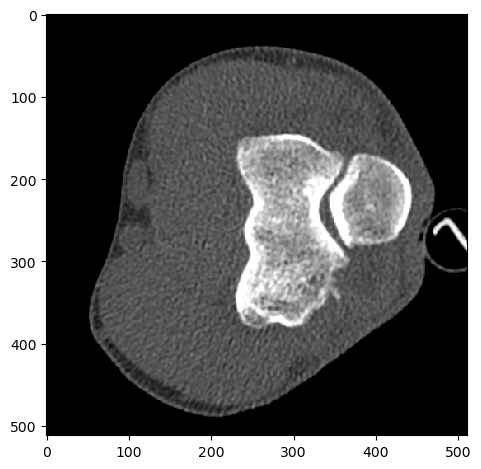

In [30]:
CT = rgb2gray(io.imread(folder_path + "ElbowCTSlice.png"))
io.imshow(CT)

#### Use gaussian filter

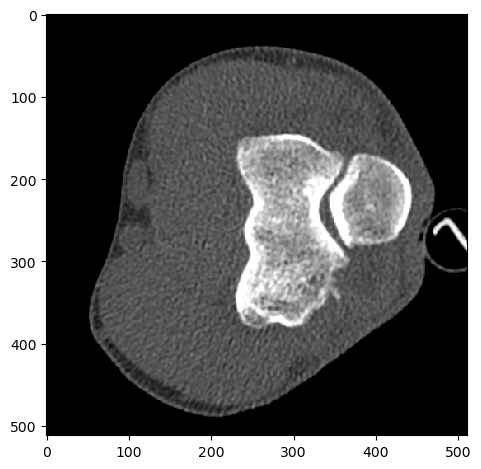

In [41]:
sigma = 0.1
gaussian_img = gaussian(CT, sigma)
io.imshow(gaussian_img)
plt.show()

#### Prewitt filter

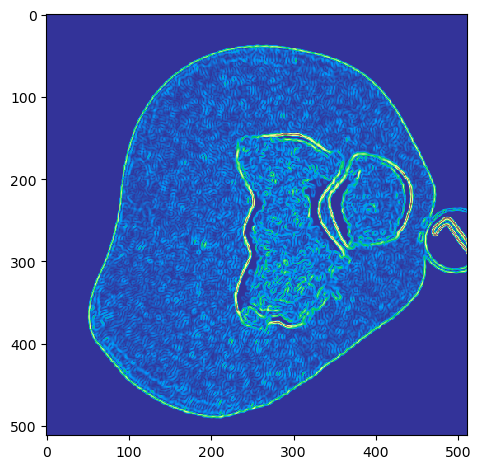

In [43]:
edge_img = prewitt(gaussian_img)
min_val = edge_img.min()
max_val = edge_img.max()
io.imshow(edge_img, vmin=min_val, vmax=max_val, cmap="terrain")


### Otsu's thresholding

In [44]:
def threshold_image(img: np.array, thresh: float):
    """
    Obtains a threshold image

    Args:
        img (np.array): input image
        threshold (float): gamma coefficient

    Return:
        threshold_img (np.array): newly mapped image
    """
    return img > thresh

[]

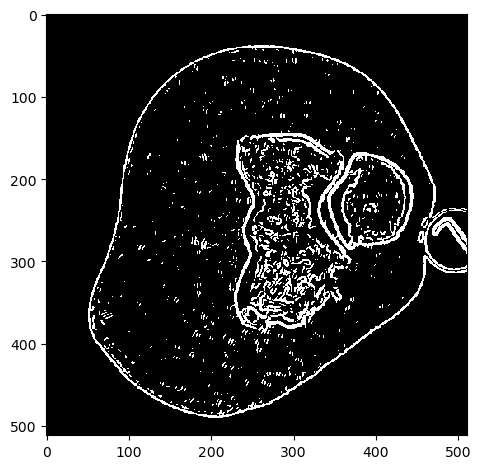

In [45]:
from skimage.filters import threshold_otsu

threshold = threshold_otsu(edge_img)
otsu_img = threshold_image(edge_img, threshold)
io.imshow(otsu_img)
plt.plot()

In [46]:
from skimage import color
from skimage.util import img_as_ubyte
from skimage.util import img_as_float
from skimage.filters import prewitt
from skimage.filters import threshold_otsu
from skimage.filters import median
import time
import cv2
import numpy as np


def show_in_moved_window(win_name, img, x, y):
    """
    Show an image in a window, where the position of the window can be given
    """
    cv2.namedWindow(win_name)
    cv2.moveWindow(win_name, x, y)
    cv2.imshow(win_name, img)


def process_gray_image(img):
    """
    Do a simple processing of an input gray scale image and return the processed image.
    # https://scikit-image.org/docs/stable/user_guide/data_types.html#image-processing-pipeline
    """
    # Do something here:
    proc_img = img.copy()
    return img_as_ubyte(proc_img)


def process_rgb_image(img):
    """
    Simple processing of a color (RGB) image
    """
    # Copy the image information so we do not change the original image
    proc_img = img.copy()
    r_comp = proc_img[:, :, 0]
    proc_img[:, :, 0] = 1 - r_comp
    return proc_img


def capture_from_camera_and_show_images():
    print("Starting image capture")

    print("Opening connection to camera")
    url = 0
    use_droid_cam = False
    if use_droid_cam:
        url = "http://192.168.1.120:4747/video"
    cap = cv2.VideoCapture(url)
    if not cap.isOpened():
        print("Cannot open camera")
        exit()

    print("Starting camera loop")
    # To keep track of frames per second using a high-performance counter
    old_time = time.perf_counter()
    fps = 0
    stop = False
    process_rgb = False
    while not stop:
        ret, new_frame = cap.read()
        if not ret:
            print("Can't receive frame. Exiting ...")
            break

        # Change from OpenCV BGR to scikit image RGB
        new_image = new_frame[:, :, ::-1]
        new_image_gray = color.rgb2gray(new_image)
        if process_rgb:
            proc_img = process_rgb_image(new_image)
            # convert back to OpenCV BGR to show it
            proc_img = proc_img[:, :, ::-1]
        else:
            proc_img = process_gray_image(new_image_gray)

        # update FPS - but do it slowly to avoid fast changing number
        new_time = time.perf_counter()
        time_dif = new_time - old_time
        old_time = new_time
        fps = fps * 0.95 + 0.05 * 1 / time_dif

        # Put the FPS on the new_frame
        str_out = f"fps: {int(fps)}"
        font = cv2.FONT_HERSHEY_COMPLEX
        cv2.putText(new_frame, str_out, (100, 100), font, 1, 255, 1)

        # Display the resulting frame
        show_in_moved_window("Input", new_frame, 0, 10)
        show_in_moved_window("Input gray", new_image_gray, 600, 10)
        show_in_moved_window("Processed image", proc_img, 1200, 10)

        if cv2.waitKey(1) == ord("q"):
            stop = True

    print("Stopping image loop")
    cap.release()
    cv2.destroyAllWindows()


if __name__ == "__main__":
    capture_from_camera_and_show_images()

Starting image capture
Opening connection to camera
Starting camera loop


KeyboardInterrupt: 